<a href="https://colab.research.google.com/github/shalinimb180-dot/BIBLIOTRACK/blob/main/EVT_CLIP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for file in files:
            if file.endswith(".zip"):
                        print(os.path.join(root, file))

/content/drive/MyDrive/Miniproject1.zip
/content/drive/MyDrive/miniproject2.zip
/content/drive/MyDrive/Assessment_2.ipynb.zip
/content/drive/MyDrive/Shalini MB Telcom logistic regression.zip
/content/drive/MyDrive/ShaliniMBminor project5.zip
/content/drive/MyDrive/MV-TeCh ad.zip


In [3]:
import zipfile
import os

# Path to your ZIP file
zip_path = "/content/drive/MyDrive/MV-TeCh ad.zip"

# Folder where the dataset will be extracted
extract_path = "/content/mvtec"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

    print("✅ Dataset extracted successfully!")

✅ Dataset extracted successfully!


In [4]:
import os

print(os.listdir("/content/mvtec"))

['carpet', 'metal_nut', 'license.txt', 'leather', 'toothbrush', 'bottle', 'capsule', 'zipper', 'tile', 'transistor', 'wood', 'screw', 'pill', 'readme.txt', 'cable', 'grid', 'hazelnut']


In [5]:
!pip install -q open_clip_torch
!pip install -q timm
!pip install -q opencv-python
!pip install -q albumentations
!pip install -q scikit-learn
!pip install -q matplotlib
!pip install -q tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [6]:
import os
import cv2
import torch
import open_clip
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm
from torchvision import transforms

In [7]:
print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", device)

if device == "cuda":
    print(torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA Available: True
Using: cuda
Tesla T4


In [8]:
model, _, preprocess = open_clip.create_model_and_transforms(
    "ViT-L-14-336",
    pretrained="openai"
)

tokenizer = open_clip.get_tokenizer("ViT-L-14-336")

model = model.to(device)
model.eval()

print("✅ CLIP Loaded Successfully")

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B / 1.71GB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ CLIP Loaded Successfully


In [9]:
dataset_path = "/content/mvtec"

print(os.listdir(dataset_path))

['carpet', 'metal_nut', 'license.txt', 'leather', 'toothbrush', 'bottle', 'capsule', 'zipper', 'tile', 'transistor', 'wood', 'screw', 'pill', 'readme.txt', 'cable', 'grid', 'hazelnut']


(np.float64(-0.5), np.float64(899.5), np.float64(899.5), np.float64(-0.5))

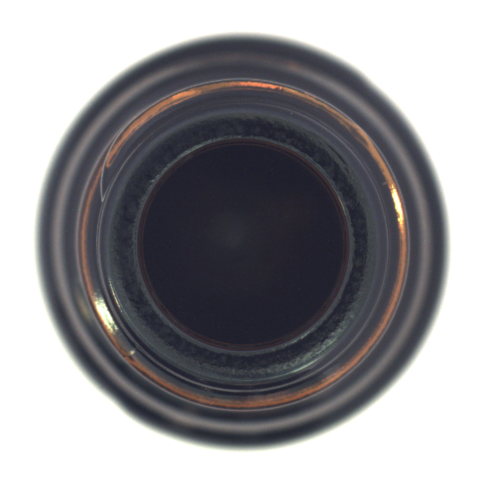

In [10]:
sample = "/content/mvtec/bottle/train/good"

images = os.listdir(sample)

img = Image.open(os.path.join(sample, images[0]))

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

In [11]:
image = preprocess(img).unsqueeze(0).to(device)

print(image.shape)

torch.Size([1, 3, 336, 336])


In [12]:
with torch.no_grad():
      image_features = model.encode_image(image)

      print(image_features.shape)

torch.Size([1, 768])


In [13]:
text = tokenizer([
      "a normal industrial product",
          "a defective industrial product"
          ]).to(device)

with torch.no_grad():
    text_features = model.encode_text(text)

    print(text_features.shape)

torch.Size([2, 768])


In [14]:
similarity = image_features @ text_features.T

print(similarity)

tensor([[73.3172, 71.5649]], device='cuda:0')


In [15]:
import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader

In [16]:
class MVTecDataset(Dataset):

    def __init__(self,
                 root_dir,
                 category,
                 split="train",
                 transform=None):

        self.transform = transform
        self.image_paths = []

        self.split_path = os.path.join(root_dir, category, split)

        for defect in sorted(os.listdir(self.split_path)):

            defect_folder = os.path.join(self.split_path, defect)

            if os.path.isdir(defect_folder):

                for img in sorted(os.listdir(defect_folder)):

                    if img.endswith(".png"):

                        self.image_paths.append(
                            os.path.join(defect_folder, img)
                        )

    def __len__(self):

        return len(self.image_paths)

    def __getitem__(self, idx):

        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:

            image = self.transform(image)

        return image, img_path

In [17]:
dataset = MVTecDataset(
    root_dir="/content/mvtec",
    category="bottle",
    split="train",
    transform=preprocess
)

print("Total Images :", len(dataset))

Total Images : 209


In [18]:
loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [19]:
images, paths = next(iter(loader))

print(images.shape)

print(paths[0])

torch.Size([8, 3, 336, 336])
/content/mvtec/bottle/train/good/000.png


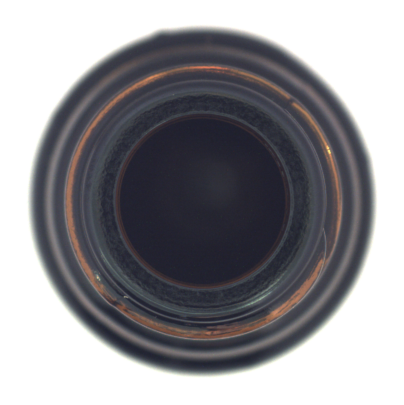

In [20]:
import matplotlib.pyplot as plt

img = Image.open(paths[0])

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [21]:
images = images.to(device)

with torch.no_grad():

    image_features = model.encode_image(images)

print(image_features.shape)

torch.Size([8, 768])


In [22]:
image_features = image_features / image_features.norm(
    dim=-1,
    keepdim=True
)

print(image_features.shape)

torch.Size([8, 768])


In [23]:
import os

os.makedirs("/content/features", exist_ok=True)

torch.save(
    image_features.cpu(),
    "/content/features/bottle_features.pt"
)

print("✅ Features Saved Successfully")

✅ Features Saved Successfully


In [24]:
import torch
import torch.nn as nn

class DAEP(nn.Module):

    def __init__(self,
                 image_dim=768,
                 prompt_dim=768):

        super().__init__()

        self.fc = nn.Sequential(

            nn.Linear(image_dim, 512),

            nn.ReLU(),

            nn.Linear(512, prompt_dim)

        )

    def forward(self, image_feature):

        dynamic_prompt = self.fc(image_feature)

        return dynamic_prompt

In [25]:
import torch
import torch.nn as nn

class DAEP(nn.Module):

    def __init__(self,
                 image_dim=768,
                 prompt_dim=768):

        super().__init__()

        self.fc = nn.Sequential(

            nn.Linear(image_dim, 512),

            nn.ReLU(),

            nn.Linear(512, prompt_dim)

        )

    def forward(self, image_feature):

        dynamic_prompt = self.fc(image_feature)

        return dynamic_prompt

In [27]:
daep = DAEP().to(device)

print(daep)

DAEP(
  (fc): Sequential(
    (0): Linear(in_features=768, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=768, bias=True)
  )
)


In [28]:
dynamic_prompt = daep(image_features)

print(dynamic_prompt.shape)

torch.Size([8, 768])


In [29]:
dynamic_prompt = dynamic_prompt / dynamic_prompt.norm(
    dim=-1,
    keepdim=True
)

In [30]:
print(dynamic_prompt[0][:10])

tensor([ 0.0532,  0.0792,  0.0297,  0.0348, -0.0112,  0.0534,  0.0144, -0.0143,
        -0.0539,  0.0053], device='cuda:0', grad_fn=<SliceBackward0>)


In [31]:
import torch
import torch.nn as nn

class LearnablePrompt(nn.Module):
    def __init__(self,
                 num_tokens=8,
                 embed_dim=768):

        super().__init__()

        self.prompt = nn.Parameter(
            torch.randn(num_tokens, embed_dim)
        )

    def forward(self, batch_size):

        return self.prompt.unsqueeze(0).repeat(
            batch_size,
            1,
            1
        )

In [32]:
learnable_prompt = LearnablePrompt().to(device)

prompt_tokens = learnable_prompt(
    image_features.shape[0]
)

print(prompt_tokens.shape)

torch.Size([8, 8, 768])
